# Lab: Data Quality & Data Cleaning for Data Warehouse

**สถานการณ์:** เป็น Data Engineer ของร้านค้าออนไลน์ ต้องเตรียมไฟล์ `e_commerce_raw.csv`
ให้พร้อมก่อนโหลดเข้า Data Warehouse

notebook นี้ทำครบทุก TODO ของใบงาน `01_student_lab.ipynb` และตอบคำถามทั้ง 5 ข้อ + Reflection
โดยวางคำตอบไว้ท้าย Task ที่เกี่ยวข้อง แล้วสรุปคำตอบทั้งหมดอีกครั้งท้าย notebook

| ใบงาน | หัวข้อใน notebook นี้ | คำตอบ |
|---|---|---|
| TODO 1 + คำถาม 1 | Task 1 — Data Profiling | ตาราง 12 ปัญหา ครบทั้ง 6 มิติ |
| TODO 2.1–2.3 + คำถาม 2 | Task 2 — Completeness | ท้าย Task 2 |
| TODO 3.1–3.3 + คำถาม 3 | Task 3 — Consistency | ท้าย Task 3 |
| TODO 4.1–4.2 (Bonus) | Task 4 — Uniqueness | หัวข้อ "ข้อจำกัดของ Exact Match" |
| TODO 5.1–5.4 + คำถาม 4 | Task 5 — Accuracy & Validity | ท้าย Task 5 |
| TODO 6.1–6.4 + คำถาม 5 | Task 6 — Outliers (IQR + Capping) | ท้าย Task 6 |
| TODO 7 + TODO 8.1–8.2 | Task 7 — Timeliness, Report, Export | `data/e_commerce_clean.csv`, `data/data_quality_report.csv` |
| Reflection + Checklist | ท้าย notebook | — |

**หลักการที่ยึดตลอดทั้ง notebook**

1. **ติด flag ก่อนแก้ค่าเสมอ** เพื่อให้ย้อนตรวจได้ว่าแถวไหนถูกแตะและด้วยเหตุผลใด (คอลัมน์ flag 11 ตัวถูกส่งออกไปด้วย)
2. **ไม่ drop แถวเพราะบางคอลัมน์ว่าง** — Fact row และยอดขายต้องไม่หาย
3. **ไม่แก้ค่าที่ต้องใช้ business context ตัดสิน** (ยอดโปรโมชัน ยอดไม่ตรงสูตร ยอดติดลบ) ติด flag ไว้ให้ฝ่ายธุรกิจตรวจ
4. **ทุก mapping มี coverage check** ถ้าเจอค่าที่ยังไม่รู้จักจะ error ทันที ไม่เงียบกลายเป็น `Unknown`

> ไฟล์ผลลัพธ์ทั้งสองไฟล์ export ไว้ที่โฟลเดอร์ `data/` (path constant มาจาก `dq_lab.py` จึงไม่ต้องเขียนชื่อไฟล์ซ้ำสองที่)

In [1]:
%matplotlib inline
import re

import matplotlib.pyplot as plt
import pandas as pd

from dq_lab import (
    GENDER_MAP, PAYMENT_MAP, STATUS_MAP,
    VALID_GENDER, VALID_PAYMENT, VALID_STATUS,
    QUANTITY_MIN, QUANTITY_MAX, TIMELINESS_SLA_HOURS, ENCODING,
    RAW_PATH, REF_PATH, CLEAN_PATH, REPORT_PATH,
    resolve_order_date, _normalize_text, _normalize_name, _date_format_breakdown,
)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

# ใช้ path constant จาก dq_lab.py เพื่อไม่ต้องเขียนชื่อไฟล์ซ้ำสองที่ (ไฟล์ข้อมูลอยู่ในโฟลเดอร์ data/)
raw = pd.read_csv(RAW_PATH, encoding=ENCODING)
ref = pd.read_csv(REF_PATH, encoding=ENCODING)
print("e_commerce_raw.csv    :", raw.shape)
print("customer_reference.csv:", ref.shape)
metrics = {}

e_commerce_raw.csv    : (630, 16)
customer_reference.csv: (167, 4)


---
## Task 1 — Data Profiling

สำรวจข้อมูลก่อนแก้อะไรทั้งสิ้น เพื่อรู้ว่ามีปัญหาอะไรและใหญ่แค่ไหน

In [2]:
print("จำนวนแถว/คอลัมน์:", raw.shape)
raw.info()

จำนวนแถว/คอลัมน์: (630, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      630 non-null    object 
 1   Customer_ID         630 non-null    object 
 2   Customer_Name       630 non-null    object 
 3   Customer_Email      580 non-null    object 
 4   Gender              630 non-null    object 
 5   Province            618 non-null    object 
 6   Order_Date          630 non-null    object 
 7   Load_Timestamp      630 non-null    object 
 8   Product_Category    630 non-null    object 
 9   Quantity            630 non-null    int64  
 10  Unit_Price          630 non-null    float64
 11  Discount_Rate       630 non-null    float64
 12  Transaction_Amount  630 non-null    float64
 13  Payment_Method      630 non-null    object 
 14  Order_Status        630 non-null    object 
 15  Is_Promotion        630 non-n

In [3]:
raw.head(5)

,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion
0,T000127,C0103,Tee Phromla,tee.phromla103@example.com,female,Phuket,2026-06-11,2026-06-11 05:00:00,Sports,3,110.26,0.05,314.24,PP,Cancelled,N
1,T000169,C0138,Mint Dechawat,mint.dechawat138@example.com,M,Khon Kaen,2026-01-24,2026-01-24 01:00:00,Home,3,138.08,0.05,393.53,PromptPay,Processing,N
2,T000003,C0071,Aom Sukjai,aom.sukjai71@example.com,m,Chanthaburi,05/29/2026,2026-05-29 05:00:00,Home,4,263.93,0.00,1055.72,COD,Cancelled,N
3,T000336,C0152,Tee Dechawat,tee.dechawat152@example.com,male,Chanthaburi,02/01/2026,2026-02-01 18:00:00,Food,6,116.53,0.10,629.26,Transfer,Returned,N
4,T000093,C0090,Mook Sukjai,mook.sukjai90@example.com,M,Chanthaburi,2026-04-18,2026-04-18 13:00:00,Electronics,5,358.35,0.00,1791.75,promptpay,Processing,N


In [4]:
nulls = raw.isnull().sum()
print("Missing values รายคอลัมน์:")
print(nulls[nulls > 0].to_string())

print(f"\nExact duplicates (ซ้ำทั้งแถว) = {raw.duplicated().sum()} แถว")
print(f"Transaction_ID ซ้ำ            = {raw['Transaction_ID'].duplicated().sum()} แถว")

Missing values รายคอลัมน์:
Customer_Email    50
Province          12

Exact duplicates (ซ้ำทั้งแถว) = 18 แถว
Transaction_ID ซ้ำ            = 18 แถว


In [5]:
raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction_ID,630,612,T000214,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,630,170,C0179,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Name,630,121,Pim Srisawat,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Email,580,167,jane.chaiyo179@example.com,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,630,10,female,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Province,618,8,Nakhon Ratchasima,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,630,365,2026-02-26,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Load_Timestamp,630,553,2026-04-03 17:00:00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Category,630,6,Food,119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,630.0,NaN,NaN,NaN,3.660317,4.184784,-3.0,2.0,3.0,5.0,99.0


In [6]:
# ความหลากหลายของค่าใน categorical column = ต้นตอของปัญหา Consistency
for col in ["Gender", "Payment_Method", "Order_Status", "Is_Promotion"]:
    vc = raw[col].value_counts(dropna=False)
    print(f"[{col}] {vc.size} ค่าที่แตกต่างกัน -> {vc.to_dict()}\n")

print("รูปแบบของ Order_Date:")
print(_date_format_breakdown(raw["Order_Date"]).to_string())

[Gender] 10 ค่าที่แตกต่างกัน -> {'female': 80, 'MALE': 79, 'M': 76, 'Male': 68, 'm': 64, 'male': 57, 'Female': 54, 'F': 52, 'f': 52, 'FEMALE': 48}

[Payment_Method] 14 ค่าที่แตกต่างกัน -> {'Transfer': 64, 'Bank Transfer': 55, 'Credit Card': 54, 'COD': 54, 'promptpay': 53, 'bank_transfer': 44, 'Cash on Delivery': 44, 'Prompt Pay': 42, 'PromptPay': 41, 'PP': 37, 'cash': 37, 'credit card': 37, 'CC': 35, 'Card': 33}

[Order_Status] 7 ค่าที่แตกต่างกัน -> {'Processing': 165, 'Completed': 162, 'Cancelled': 148, 'Returned': 139, 'done': 6, 'Cancel': 5, 'unknown_status': 5}

[Is_Promotion] 2 ค่าที่แตกต่างกัน -> {'N': 603, 'Y': 27}

รูปแบบของ Order_Date:
YYYY-MM-DD              351
xx/xx/YYYY (กำกวม)      170
YYYY/MM/DD               60
xx-xx-YYYY (กำกวม)       47
OTHER (ไม่ใช่วันที่)      2


In [7]:
qty_bad = int((~raw["Quantity"].between(QUANTITY_MIN, QUANTITY_MAX)).sum())
amt_neg = int((raw["Transaction_Amount"] < 0).sum())
print(f"Quantity นอกช่วง {QUANTITY_MIN}-{QUANTITY_MAX} = {qty_bad} แถว "
      f"(min={raw['Quantity'].min()}, max={raw['Quantity'].max()})")
print(f"Transaction_Amount ติดลบ = {amt_neg} แถว "
      f"(min={raw['Transaction_Amount'].min():,.2f}, max={raw['Transaction_Amount'].max():,.2f})")

metrics.update(
    rows_raw=len(raw),
    missing_email_before=int(nulls.get("Customer_Email", 0)),
    missing_province_before=int(nulls.get("Province", 0)),
    exact_duplicates_before=int(raw.duplicated().sum()),
    distinct_gender_before=int(raw["Gender"].nunique(dropna=False)),
    distinct_payment_before=int(raw["Payment_Method"].nunique(dropna=False)),
    distinct_status_before=int(raw["Order_Status"].nunique(dropna=False)),
    invalid_quantity_before=qty_bad,
    negative_amount_before=amt_neg,
    total_amount_before=float(raw["Transaction_Amount"].sum()),
)
metrics

Quantity นอกช่วง 1-20 = 3 แถว (min=-3, max=99)
Transaction_Amount ติดลบ = 2 แถว (min=-500.00, max=999,999.00)


{'rows_raw': 630,
 'missing_email_before': 50,
 'missing_province_before': 12,
 'exact_duplicates_before': 18,
 'distinct_gender_before': 10,
 'distinct_payment_before': 14,
 'distinct_status_before': 7,
 'invalid_quantity_before': 3,
 'negative_amount_before': 2,
 'total_amount_before': 3838144.59}

### คำถาม 1 — ปัญหาที่พบ จับคู่กับมิติ Data Quality

โจทย์ขออย่างน้อย **5 ปัญหา / 3 มิติ** — ตารางนี้ระบุ **12 ปัญหา ครบทั้ง 6 มิติ** พร้อมหลักฐานจากข้อมูลจริง

| ปัญหาที่พบ | คอลัมน์ | มิติ Data Quality | หลักฐาน / จำนวนแถว | แนวทางจัดการ |
|---|---|---|---|---|
| ค่าว่าง ไม่มีอีเมลลูกค้า | `Customer_Email` | **Completeness** | 50 แถว | เติมจาก `customer_reference.csv` ก่อน แล้ว fallback `unknown_<ID>@unknown.local` + ติด flag |
| ค่าว่าง ไม่มีจังหวัด | `Province` | **Completeness** | 12 แถว | เติมจาก reference ได้ 8 แถว ที่เหลือ 4 แถวเป็น `Unknown` เพราะ reference เองก็ว่าง |
| ค่าเดียวกันเขียนหลายแบบ | `Gender` | **Consistency** | 10 รูปแบบ (`M`, `m`, `Male`, `MALE`, `male`, `F`, `f`, `Female`, `FEMALE`, `female`) | map เป็น `M` / `F` / `Unknown` |
| ค่าเดียวกันเขียนหลายแบบ | `Payment_Method` | **Consistency** | 14 รูปแบบ (`CC`, `Card`, `credit card`, `PP`, `promptpay`, `COD`, `cash`, `Transfer`, `bank_transfer`, …) | map เป็น 4 ค่ามาตรฐาน + `Unknown` |
| วันที่มีหลายรูปแบบ และกำกวมระหว่าง DD/MM กับ MM/DD | `Order_Date` | **Consistency** | `YYYY-MM-DD` 351, `xx/xx/YYYY` 170, `YYYY/MM/DD` 60, `xx-xx-YYYY` 47, `not_a_date` 2 | parse รายแถว ใช้ `Load_Timestamp` เป็นหลักฐานตัดสิน + เก็บวิธีที่ใช้ไว้ในคอลัมน์ |
| แถวซ้ำทั้งแถว | ทุกคอลัมน์ | **Uniqueness** | 18 แถว (`Transaction_ID` ซ้ำ 18 ตัว) | `drop_duplicates(keep="first")` |
| ลูกค้าคนเดียวกันแต่ชื่อเขียนต่างกัน (near duplicate) | `Customer_Name` | **Uniqueness** | `C0047`: `Ploy  Saelim` (สองช่องว่าง) vs `Ploy Saelim` | normalize + รายงานไว้ **ไม่ลบอัตโนมัติ** |
| จำนวนสินค้าเป็นไปไม่ได้ | `Quantity` | **Validity** | 3 แถว (พบ `0`, `-3`, `99`) | ติด flag แล้ว `clip(1, 20)` |
| สถานะไม่อยู่ในชุดที่กำหนด | `Order_Status` | **Validity** | `done` 6, `Cancel` 5, `unknown_status` 5 | standardize + ติด `Status_Was_Invalid` |
| ยอดเงินติดลบ | `Transaction_Amount` | **Validity** | 2 แถว (`-1.00`, `-500.00`) | ติด flag ไว้ ไม่แก้ค่า (อาจเป็น refund) |
| ยอดไม่ตรงสูตร `Qty × Price × (1 − Disc)` | `Transaction_Amount` | **Accuracy** | 49 แถว (เป็นโปรโมชัน 7 แถว) | ติด `Accuracy_Flag` **ไม่แก้ยอดอัตโนมัติ** (ดูคำถาม 4) |
| ค่า sentinel ของระบบต้นทาง | `Transaction_Amount` | **Accuracy** | 4 แถว (`666666`, `777777`, `888888`, `999999`) รวม 3,333,330 บาท | IQR capping เฉพาะรายการที่ไม่ใช่โปรโมชัน |
| ข้อมูลเข้าคลังช้ากว่า SLA 24 ชม. | `Load_Timestamp` − `Order_Date` | **Timeliness** | 38 แถว (6.2%) delay สูงสุด 118 ชม. | คำนวณ `Load_Delay_Hours` + ติดป้าย `Late` |

**ข้อสังเกตจาก profiling**

- ปัญหาที่ "ตาเห็น" มีแค่ค่าว่างกับตัวพิมพ์ไม่ตรงกัน แต่ปัญหาที่กระทบยอดเงินจริง (sentinel 4 แถว = 87% ของยอดรวมดิบ)
  ต้องดูจาก `describe()` ถึงจะเจอ — `max` ของ `Transaction_Amount` คือ 999,999 ขณะที่ median อยู่แถว 600 บาท
- `Transaction_ID` ซ้ำ 18 ตัว เท่ากับจำนวนแถวซ้ำทั้งแถวพอดี แปลว่าเป็นการโหลดซ้ำ (double load) ไม่ใช่ ID ชนกัน

---
## Task 2 — Completeness

**ลำดับสำคัญ:** ติด flag ก่อน → เติมจาก reference (conformed dimension) → เติม placeholder ที่ traceable

In [8]:
df = raw.copy()

# 1) ติด flag ก่อนแก้ค่า
df["Customer_Email_Was_Missing"] = df["Customer_Email"].isna()
df["Province_Was_Missing"] = df["Province"].isna()
print(f"Customer_Email_Was_Missing = {df['Customer_Email_Was_Missing'].sum()} แถว")
print(f"Province_Was_Missing       = {df['Province_Was_Missing'].sum()} แถว")

Customer_Email_Was_Missing = 50 แถว
Province_Was_Missing       = 12 แถว


In [9]:
# ผลกระทบถ้าเลือกทางง่ายคือ dropna() -> ยอดขายและ Fact row หายไปจริง
lost = float(df.loc[df["Customer_Email_Was_Missing"], "Transaction_Amount"].sum())
total = float(df["Transaction_Amount"].sum())
print(f"ถ้า drop แถวที่ Customer_Email หาย: เสีย Fact row {int(df['Customer_Email_Was_Missing'].sum())} แถว")
print(f"ยอดขายที่สูญหาย = {lost:,.2f} บาท จากทั้งหมด {total:,.2f} บาท ({lost / total * 100:.2f}%)")
metrics["sales_at_risk_if_dropped"] = lost

ถ้า drop แถวที่ Customer_Email หาย: เสีย Fact row 50 แถว
ยอดขายที่สูญหาย = 39,254.24 บาท จากทั้งหมด 3,838,144.59 บาท (1.02%)


In [10]:
# 2) เติมจาก customer_reference.csv ตาม Customer_ID (ต้องมั่นใจว่า key ไม่ซ้ำ ไม่งั้น merge จะขยายแถว)
assert not ref["Customer_ID"].duplicated().any()

merged = df.merge(ref[["Customer_ID", "Customer_Email", "Province"]],
                  on="Customer_ID", how="left", suffixes=("", "_ref"))
assert len(merged) == len(df)

merged["Customer_Email_Filled_From_Reference"] = merged["Customer_Email"].isna() & merged["Customer_Email_ref"].notna()
merged["Province_Filled_From_Reference"] = merged["Province"].isna() & merged["Province_ref"].notna()
merged["Customer_Email"] = merged["Customer_Email"].fillna(merged["Customer_Email_ref"])
merged["Province"] = merged["Province"].fillna(merged["Province_ref"])
df = merged.drop(columns=["Customer_Email_ref", "Province_ref"])

print(f"Customer_Email เติมจาก reference ได้ {df['Customer_Email_Filled_From_Reference'].sum()}/50 แถว")
print(f"Province       เติมจาก reference ได้ {df['Province_Filled_From_Reference'].sum()}/12 แถว")
print(f"\nreference เองมี Province ว่าง {ref['Province'].isna().sum()} ราย -> "
      "จึงเติมไม่ครบทั้ง 12 แถว ต้องใช้ 'Unknown' ต่อ")

Customer_Email เติมจาก reference ได้ 47/50 แถว
Province       เติมจาก reference ได้ 8/12 แถว

reference เองมี Province ว่าง 3 ราย -> จึงเติมไม่ครบทั้ง 12 แถว ต้องใช้ 'Unknown' ต่อ


In [11]:
# 3) ที่เหลือใช้ placeholder ที่ traceable กลับไปหาลูกค้าได้ (ไม่ใช่ค่าสุ่มหรือค่าว่าง)
still_missing = df["Customer_Email"].isna()
df.loc[still_missing, "Customer_Email"] = (
    "unknown_" + df.loc[still_missing, "Customer_ID"].astype(str) + "@unknown.local"
)
df["Province"] = df["Province"].fillna("Unknown")

print(f"เติม unknown_<Customer_ID>@unknown.local : {int(still_missing.sum())} แถว")
print(df.loc[still_missing, ["Transaction_ID", "Customer_ID", "Customer_Email"]].to_string(index=False))
print(f"\nProvince -> 'Unknown' : {int(df['Province_Was_Missing'].sum() - df['Province_Filled_From_Reference'].sum())} แถว")

assert df["Customer_Email"].notna().all() and df["Province"].notna().all()
assert len(df) == metrics["rows_raw"], "จำนวนแถวต้องไม่เปลี่ยน — ห้าม drop"
print(f"\nจำนวนแถวยังครบ {len(df)} แถว")

เติม unknown_<Customer_ID>@unknown.local : 3 แถว
Transaction_ID Customer_ID              Customer_Email
       T000038       C0129 unknown_C0129@unknown.local
       T000151       C0003 unknown_C0003@unknown.local
       T000451       C0054 unknown_C0054@unknown.local

Province -> 'Unknown' : 4 แถว

จำนวนแถวยังครบ 630 แถว


### คำถาม 2 — ทำไม `dropna()` ทำให้ยอดขายผิดเพี้ยน และทำไม mean imputation ใช้กับอีเมลไม่ได้

#### ก) ผลของ `dropna(subset=["Customer_Email"])` ต่อยอดขายใน Data Warehouse

ข้อมูลดิบมี `Customer_Email` ว่าง **50 แถว** (เหลือ 48 แถวหลังลบแถวซ้ำ) ซึ่งบรรจุยอดขายรวม **39,254.24 บาท**
คิดเป็น **1.02%** ของยอดดิบทั้งหมด หรือ **7.78%** เมื่อตัดค่า sentinel 4 แถว (3,333,330 บาท ที่ไม่ใช่ยอดจริง)
ออกจากตัวหาร ถ้า drop ทิ้งจะเกิดผลดังนี้

1. **ยอดขายรวมหายไปทันที 39,254.24 บาท** — และหายแบบเงียบ ๆ ไม่มีร่องรอยว่าเคยมี ไม่มีใครรู้ว่าต้องไปตามคืนจากไหน
2. **เสีย Fact row 50 รายการ** — transaction count, average order value, ยอดตามหมวดสินค้า และยอดตามจังหวัด
   จะต่ำกว่าความจริงทั้งหมด กระทบทุกรายงานที่ต่อยอดจากตารางนี้
3. **เกิด bias เชิงระบบ ไม่ใช่ error แบบสุ่ม** — ถ้าอีเมลหายเพราะช่องทางขายบางช่องทางไม่เก็บอีเมล (เช่นขายหน้าร้าน)
   การ drop จะตัดยอดของช่องทางนั้นออกเกือบทั้งหมด แล้วสรุปผิดว่าช่องทางนั้นขายไม่ดี
4. **ผิดหลักการของ Data Warehouse** — อีเมลเป็น attribute ของ **dimension (ลูกค้า)** ไม่ใช่ measure ของ **fact (ธุรกรรม)**
   การที่ attribute ของ dimension ขาด ไม่ใช่เหตุผลให้ทิ้งข้อเท็จจริงว่า "มีการขายเกิดขึ้นจริง"

#### ข) ทำไม mean/mode imputation ใช้กับ `Customer_Email` ไม่ได้

1. **ผิดชนิดข้อมูล** — `mean` ใช้กับตัวเลขที่ค่าเฉลี่ยมีความหมาย อีเมลเป็น categorical/text ไม่มี "ค่ากลาง"
2. **อีเมลเป็น identifier ไม่ใช่การวัด** — ถ้าเติมด้วยค่าที่พบบ่อยที่สุด (mode) จะกลายเป็นการยกธุรกรรมของคนหนึ่ง
   ไปให้ลูกค้าอีกคน ทำให้ยอดขายรายลูกค้า, RFM, CLV ผิดทั้งหมด
3. **พัง Uniqueness** — อีเมลถูกใช้เป็น secondary unique key ถ้าเติมค่าซ้ำกันหลายแถวจะสร้าง near duplicate ปลอมขึ้นมาเอง
4. **สร้าง PII ปลอม** — อีเมลที่แต่งขึ้นอาจตรงกับอีเมลจริงของคนอื่น เสี่ยงส่งข้อมูล/โปรโมชันผิดคน

#### ค) สิ่งที่ทำแทนใน lab นี้

เติมจาก `customer_reference.csv` ตาม `Customer_ID` ได้ **47 แถว** (conformed dimension — เป็นข้อมูลจริง ไม่ใช่การเดา)
เหลือเพียง **3 แถว** ที่ต้องใช้ placeholder แบบ **traceable** คือ `unknown_<Customer_ID>@unknown.local`
คู่กับ flag `Customer_Email_Was_Missing` ส่วน `Province` ใช้สมาชิก `Unknown` ตามแนวทาง **Unknown member**
ของ dimension ผลคือ **ยอดขายรวมยังครบ 100% ทุกบาท** และยังตามรอยกลับไปหาต้นทางได้

---
## Task 3 — Consistency

In [12]:
print("Gender ก่อน:", sorted(df["Gender"].dropna().unique().tolist()))
df["Gender"] = _normalize_text(df["Gender"]).map(GENDER_MAP).fillna("Unknown")
print("Gender หลัง:", df["Gender"].value_counts().to_dict())
assert not set(df["Gender"].unique()) - VALID_GENDER

Gender ก่อน: ['F', 'FEMALE', 'Female', 'M', 'MALE', 'Male', 'f', 'female', 'm', 'male']
Gender หลัง: {'M': 344, 'F': 286}


In [13]:
print(f"Payment_Method ก่อน ({df['Payment_Method'].nunique()} รูปแบบ):",
      sorted(df["Payment_Method"].dropna().unique().tolist()))

normalized = _normalize_text(df["Payment_Method"])
# coverage check: ถ้าเจอค่าที่ mapping ไม่รู้จักต้อง error ไม่ใช่เงียบกลายเป็น Unknown
unmapped = set(normalized.dropna().unique()) - set(PAYMENT_MAP)
assert not unmapped, f"ยังไม่ได้ map: {unmapped}"

df["Payment_Method"] = normalized.map(PAYMENT_MAP).fillna("Unknown")
print("Payment_Method หลัง:", df["Payment_Method"].value_counts().to_dict())

Payment_Method ก่อน (14 รูปแบบ): ['Bank Transfer', 'CC', 'COD', 'Card', 'Cash on Delivery', 'Credit Card', 'PP', 'Prompt Pay', 'PromptPay', 'Transfer', 'bank_transfer', 'cash', 'credit card', 'promptpay']
Payment_Method หลัง: {'PromptPay': 173, 'Bank Transfer': 163, 'Credit Card': 159, 'Cash on Delivery': 135}


### การแปลง `Order_Date` ให้เป็น `YYYY-MM-DD`

ปัญหาคือ `12/04/2026` อ่านได้สองแบบ (12 เม.ย. หรือ 4 ธ.ค.) หลักฐานที่ใช้ตัดสินคือ **`Load_Timestamp`**
เพราะข้อมูลต้องถูกโหลดเข้าระบบ *หลัง* วันสั่งซื้อ — ตรวจกับข้อมูลจริงแล้วพบว่า 409 แถวที่รูปแบบไม่กำกวมมี
`Load_Timestamp − Order_Date` อยู่ระหว่าง 1 ถึง 116 ชั่วโมง **ไม่มีค่าติดลบแม้แถวเดียว** จึงใช้กฎนี้ได้

ลำดับการตัดสิน (ดู source ด้านล่าง):
1. รูปแบบ `YYYY-MM-DD` / `YYYY/MM/DD` — ไม่กำกวมอยู่แล้ว
2. รูปแบบ `xx/xx/YYYY` — สร้าง candidate ทั้ง DD/MM และ MM/DD แล้ว
   - ถ้าเหลือตัวเดียวที่เป็นวันจริงตามปฏิทิน → ตัดสินด้วยปฏิทิน (เช่น `31-01-2026` เป็นเดือน 31 ไม่ได้)
   - ถ้าเป็นวันจริงทั้งคู่ → เลือกตัวที่ delay ไม่ติดลบและน้อยที่สุด
3. อ่านไม่ได้เลย → ใช้วันของ `Load_Timestamp` และติด flag `Order_Date_Was_Imputed`

**ข้อควรระวังที่เจอจากข้อมูลจริง:** regex อย่างเดียวไม่พอ ต้อง validate ด้วยปฏิทินด้วย เพราะมีค่าอย่าง
`2026-13-05` (เดือน 13) และ `31/02/2026` (ก.พ. ไม่มีวันที่ 31) ที่รูปแบบถูกแต่ไม่ใช่วันที่จริง

In [14]:
import inspect
print(inspect.getsource(resolve_order_date))

def resolve_order_date(raw_value, load_ts: pd.Timestamp) -> tuple[pd.Timestamp, str, bool]:
    """แปลง Order_Date หนึ่งค่า คืน (วันที่, วิธีที่ใช้, ถูก impute หรือไม่)

    ลำดับการตัดสิน
      1. รูปแบบ YYYY-MM-DD / YYYY/MM/DD ไม่กำกวมอยู่แล้ว
      2. รูปแบบ xx/xx/YYYY สร้าง candidate ทั้ง DD/MM และ MM/DD
         - ถ้ามีตัวเดียวที่เป็นวันจริง -> ตัดสินด้วยปฏิทิน
         - ถ้าเป็นวันจริงทั้งคู่ -> เลือกตัวที่ Load_Timestamp - Order_Date >= 0 และน้อยที่สุด
           (ข้อมูลจริงยืนยันว่า Load_Timestamp มาทีหลัง Order_Date เสมอ)
      3. อ่านไม่ได้เลย -> fallback เป็นวันของ Load_Timestamp และติด flag
    """
    text = "" if pd.isna(raw_value) else str(raw_value).strip()

    m = ISO_DATE_RE.match(text)
    if m:
        ts = _to_timestamp(int(m[1]), int(m[2]), int(m[3]))
        if ts is not None:
            return ts, "ISO_UNAMBIGUOUS", False

    m = AMBIGUOUS_DATE_RE.match(text)
    if m:
        first, second, year = int(m[1]), int(m[2]), int(m[3])
        candidates = {}
     

In [15]:
df["Load_Timestamp"] = pd.to_datetime(df["Load_Timestamp"], errors="coerce")
assert df["Load_Timestamp"].notna().all(), "Load_Timestamp ต้องอ่านได้ทุกแถว เพราะใช้เป็นหลักฐาน"

df["Order_Date_Raw"] = df["Order_Date"]
resolved = [resolve_order_date(v, ts) for v, ts in zip(df["Order_Date_Raw"], df["Load_Timestamp"])]
df["Order_Date"] = pd.to_datetime([r[0] for r in resolved])
df["Order_Date_Parse_Method"] = [r[1] for r in resolved]
df["Order_Date_Was_Imputed"] = [r[2] for r in resolved]

print(df["Order_Date_Parse_Method"].value_counts().to_string())

Order_Date_Parse_Method
ISO_UNAMBIGUOUS                      409
RESOLVED_BY_CALENDAR (DD/MM/YYYY)     82
RESOLVED_BY_CALENDAR (MM/DD/YYYY)     49
RESOLVED_BY_LOAD_TS (DD/MM/YYYY)      42
RESOLVED_BY_LOAD_TS (MM/DD/YYYY)      36
IMPUTED_FROM_LOAD_TS                   7
IDENTICAL_EITHER_WAY                   5


In [16]:
print("แถวที่อ่านวันที่ไม่ได้เลย จึง fallback เป็นวันของ Load_Timestamp:")
print(df.loc[df["Order_Date_Was_Imputed"],
             ["Transaction_ID", "Order_Date_Raw", "Load_Timestamp", "Order_Date"]].to_string(index=False))

แถวที่อ่านวันที่ไม่ได้เลย จึง fallback เป็นวันของ Load_Timestamp:
Transaction_ID Order_Date_Raw      Load_Timestamp Order_Date
       T000141     31/02/2026 2026-06-19 06:00:00 2026-06-19
       T900007     31/02/2026 2026-04-03 17:00:00 2026-04-03
       T000439     2026-13-05 2026-05-21 17:00:00 2026-05-21
       T000124     2026-13-05 2026-06-08 03:00:00 2026-06-08
       T000409     not_a_date 2026-05-22 05:00:00 2026-05-22
       T000545     not_a_date 2026-01-24 10:00:00 2026-01-24
       T000474     31/02/2026 2026-04-03 17:00:00 2026-04-03


In [17]:
# ตรวจว่าการตัดสินวันที่ถูกต้อง: ต้องไม่มีแถวใดที่ Order_Date มาหลัง Load_Timestamp
delay = (df["Load_Timestamp"] - df["Order_Date"]).dt.total_seconds() / 3600
assert (delay >= 0).all(), f"ยังมี {int((delay < 0).sum())} แถวที่วันที่ผิด"
print(f"ผ่าน: ทุกแถวมี Load_Timestamp >= Order_Date (delay {delay.min():.0f}-{delay.max():.0f} ชม.)")

# เทียบกับการ parse แบบเหมารวม dayfirst=True เพื่อแสดงว่าทำไมต้องตัดสินรายแถว
naive = pd.to_datetime(df["Order_Date_Raw"], dayfirst=True, format="mixed", errors="coerce")
naive_delay = (df["Load_Timestamp"] - naive).dt.total_seconds() / 3600
print(f"ถ้า parse เหมารวมด้วย dayfirst=True: อ่านไม่ได้ {int(naive.isna().sum())} แถว "
      f"และได้ delay ติดลบ {int((naive_delay < 0).sum())} แถว (เป็นไปไม่ได้ในทางธุรกิจ)")

metrics["order_date_imputed"] = int(df["Order_Date_Was_Imputed"].sum())

ผ่าน: ทุกแถวมี Load_Timestamp >= Order_Date (delay 1-118 ชม.)
ถ้า parse เหมารวมด้วย dayfirst=True: อ่านไม่ได้ 5 แถว และได้ delay ติดลบ 28 แถว (เป็นไปไม่ได้ในทางธุรกิจ)


In [18]:
# ตัวอย่างวันกำกวมที่ต้องใช้ Load_Timestamp ตัดสิน (ใช้ตอบคำถามวิเคราะห์ข้อ 2)
amb = df[df["Order_Date_Parse_Method"].str.startswith("RESOLVED_BY_LOAD_TS")].copy()
amb["Delay_Hours"] = (amb["Load_Timestamp"] - amb["Order_Date"]).dt.total_seconds() / 3600
print(f"แถวที่ต้องใช้ Load_Timestamp ตัดสิน = {len(amb)} แถว\n")
print(amb[["Transaction_ID", "Order_Date_Raw", "Load_Timestamp", "Order_Date",
           "Order_Date_Parse_Method", "Delay_Hours"]].head(8).to_string(index=False))

แถวที่ต้องใช้ Load_Timestamp ตัดสิน = 78 แถว

Transaction_ID Order_Date_Raw      Load_Timestamp Order_Date          Order_Date_Parse_Method  Delay_Hours
       T000336     02/01/2026 2026-02-01 18:00:00 2026-02-01 RESOLVED_BY_LOAD_TS (MM/DD/YYYY)         18.0
       T000307     02/06/2026 2026-02-06 13:00:00 2026-02-06 RESOLVED_BY_LOAD_TS (MM/DD/YYYY)         13.0
       T000368     12-04-2026 2026-04-12 01:00:00 2026-04-12 RESOLVED_BY_LOAD_TS (DD/MM/YYYY)          1.0
       T000130     06-01-2026 2026-01-06 08:00:00 2026-01-06 RESOLVED_BY_LOAD_TS (DD/MM/YYYY)          8.0
       T000411     09-01-2026 2026-01-09 11:00:00 2026-01-09 RESOLVED_BY_LOAD_TS (DD/MM/YYYY)         11.0
       T000548     08/01/2026 2026-01-08 02:00:00 2026-01-08 RESOLVED_BY_LOAD_TS (DD/MM/YYYY)          2.0
       T000250     02/04/2026 2026-02-04 19:00:00 2026-02-04 RESOLVED_BY_LOAD_TS (MM/DD/YYYY)         19.0
       T000130     06-01-2026 2026-01-06 08:00:00 2026-01-06 RESOLVED_BY_LOAD_TS (DD/MM/YYYY)     

### คำถาม 3 — ตัวอย่างวันที่ที่ตีความได้สองแบบ และหลักฐานที่ใช้ตัดสิน

**ตัวอย่าง `T900009`** — `Order_Date = "04/03/2026"`, `Load_Timestamp = 2026-04-03 17:00:00`

| การตีความ | วันที่ที่ได้ | Load_Delay_Hours | สมเหตุสมผลหรือไม่ |
|---|---|---|---|
| `DD/MM/YYYY` | 2026-03-04 (4 มี.ค.) | ~744 ชม. (31 วัน) | ไม่ — ต้องรอเดือนหนึ่งกว่าจะโหลดเข้าระบบ ขัดกับ pattern ของระบบนี้ |
| `MM/DD/YYYY` | **2026-04-03** (3 เม.ย.) | **17 ชม.** | ใช่ — ตรงกับ delay ปกติของข้อมูลทั้งชุด |

**หลักฐาน 3 ชั้นที่ใช้ตัดสิน**

1. **ปฏิทิน** — บางค่าตัดออกได้ทันทีโดยไม่ต้องดูอะไรเพิ่ม เช่น `31-01-2026` เป็น `MM/DD` ไม่ได้เพราะไม่มีเดือนที่ 31
   (ตัดสินด้วยวิธีนี้ได้ 131 แถว)
2. **ทิศทางของเวลา** — ข้อมูลต้องถูกโหลดเข้าระบบ *หลัง* วันสั่งซื้อ ดังนั้น `Load_Timestamp − Order_Date ≥ 0` เสมอ
   การตีความที่ให้ค่าติดลบจึงเป็นไปไม่ได้
3. **การกระจายตัวของ delay ในข้อมูลที่ไม่กำกวม** — 409 แถวที่รูปแบบเป็น `YYYY-MM-DD` มี delay ระหว่าง 1–116 ชม.
   (median 10 ชม.) การตีความที่ให้ delay หลายสิบวันจึงขัดกับ pattern ของระบบ เราจึงเลือกการตีความที่ให้ delay
   **ไม่ติดลบและน้อยที่สุด** (ตัดสินด้วยวิธีนี้ได้ 78 แถว)

**หลักฐานเชิงลบที่ยืนยันว่าต้องตัดสินรายแถว:** ถ้า parse เหมารวมทั้งไฟล์ด้วย `dayfirst=True` จะได้
`Load_Delay_Hours` **ติดลบ 28 แถว** ซึ่งเป็นไปไม่ได้ในทางธุรกิจ — พิสูจน์ว่าไฟล์นี้ปนทั้งสองรูปแบบจริง

**เมื่อหลักฐานไม่พอ** (`not_a_date` 2 แถว, `31/02/2026` 3 แถว, `2026-13-05` 2 แถว) ใช้วันของ `Load_Timestamp`
เป็น fallback แต่ติด flag `Order_Date_Was_Imputed = True` ไว้ทุกแถว เพราะเป็นการเดา ไม่ใช่ข้อเท็จจริง

---
## Task 4 — Uniqueness

In [19]:
# เทียบเฉพาะคอลัมน์ต้นฉบับ เพราะคอลัมน์ flag ที่เพิ่มมาไม่ใช่เนื้อหาของธุรกรรม
business_cols = [c for c in df.columns
                 if not c.endswith(("_Was_Missing", "_From_Reference", "_Parse_Method", "_Was_Imputed", "_Raw"))]

print(f"Exact duplicate = {df.duplicated(subset=business_cols).sum()} แถว")
dup_ids = df.loc[df["Transaction_ID"].duplicated(keep=False), "Transaction_ID"].unique()[:2]
print(df[df["Transaction_ID"].isin(dup_ids)][
    ["Transaction_ID", "Customer_ID", "Order_Date", "Transaction_Amount", "Order_Status"]].to_string(index=False))

before = len(df)
df = df.drop_duplicates(subset=business_cols, keep="first").reset_index(drop=True)
print(f"\nหลัง drop_duplicates(keep='first'): {before} -> {len(df)} แถว")
assert not df["Transaction_ID"].duplicated().any()
metrics["exact_duplicates_removed"] = before - len(df)

Exact duplicate = 18 แถว
Transaction_ID Customer_ID Order_Date  Transaction_Amount Order_Status
       T000440       C0038 2026-02-23              852.84   Processing
       T000205       C0134 2026-06-28             1483.80    Cancelled
       T000440       C0038 2026-02-23              852.84   Processing
       T000205       C0134 2026-06-28             1483.80    Cancelled

หลัง drop_duplicates(keep='first'): 630 -> 612 แถว


In [20]:
# Near duplicate: ลูกค้าคนเดียวกันแต่ชื่อเขียนไม่เหมือนกัน -> ใช้ secondary key เป็นตัวจับ
df["Customer_Name_Normalized"] = _normalize_name(df["Customer_Name"]).str.title()
golden = dict(zip(ref["Customer_ID"], ref["Customer_Name"]))

rows = []
for key_col in ["Customer_ID", "Customer_Email"]:
    grouped = df.groupby(key_col)["Customer_Name"].agg(["nunique", lambda s: sorted(set(s))])
    for key, row in grouped[grouped["nunique"] > 1].iterrows():
        rows.append({"Secondary_Key": key_col, "Key_Value": key,
                     "ชื่อที่พบ": " | ".join(repr(n) for n in row.iloc[1]),
                     "Golden Record": golden.get(key, "-")})

near_dup = pd.DataFrame(rows).drop_duplicates()
print(near_dup.to_string(index=False) if not near_dup.empty else "ไม่พบ near duplicate")
metrics["near_duplicate_cases"] = len(near_dup)

 Secondary_Key                 Key_Value                      ชื่อที่พบ Golden Record
   Customer_ID                     C0047 'Ploy  Saelim' | 'Ploy Saelim'   Ploy Saelim
Customer_Email ploy.saelim47@example.com 'Ploy  Saelim' | 'Ploy Saelim'             -

In [21]:
# แสดงให้เห็นว่าทำไม drop_duplicates มองไม่เห็น: byte ไม่เท่ากันแม้ตาเห็นว่าเหมือน
pair = ["Ploy  Saelim", "Ploy Saelim"]
same_after_normalize = re.sub(r"\s+", " ", pair[0]) == pair[1]
print(f"{pair[0]!r} == {pair[1]!r} ? -> {pair[0] == pair[1]}")
print(f"normalize (บีบช่องว่างซ้ำ) แล้วเท่ากันหรือไม่ -> {same_after_normalize}")
print(f"\nแถวของลูกค้า C0047 ที่ยังอยู่ในข้อมูล (ไม่ลบ เพราะเป็นธุรกรรมต่างรายการกัน):")
print(df[df["Customer_ID"] == "C0047"][
    ["Transaction_ID", "Customer_Name", "Customer_Name_Normalized", "Order_Date", "Transaction_Amount"]
].to_string(index=False))

'Ploy  Saelim' == 'Ploy Saelim' ? -> False
normalize (บีบช่องว่างซ้ำ) แล้วเท่ากันหรือไม่ -> True

แถวของลูกค้า C0047 ที่ยังอยู่ในข้อมูล (ไม่ลบ เพราะเป็นธุรกรรมต่างรายการกัน):
Transaction_ID Customer_Name Customer_Name_Normalized Order_Date  Transaction_Amount
       T000088   Ploy Saelim              Ploy Saelim 2026-04-11             1149.15
       T900011  Ploy  Saelim              Ploy Saelim 2026-05-18              284.94
       T000413   Ploy Saelim              Ploy Saelim 2026-04-11              395.11
       T000195   Ploy Saelim              Ploy Saelim 2026-05-05             1276.88
       T900010  Ploy  Saelim              Ploy Saelim 2026-05-05             1276.88
       T000219   Ploy Saelim              Ploy Saelim 2026-02-07              212.83
       T000466   Ploy Saelim              Ploy Saelim 2026-05-16              603.85
       T000378   Ploy Saelim              Ploy Saelim 2026-05-18              284.94


### TODO 4.2 (Bonus) — ทำไม `drop_duplicates()` จึงตรวจไม่พบ Near Duplicate

`drop_duplicates()` และ `groupby()` เปรียบเทียบแบบ **ตรงตัวทุก byte** จึงมองว่า
`'Ploy  Saelim'` (สองช่องว่าง) กับ `'Ploy Saelim'` เป็นคนละค่า และในทำนองเดียวกัน
`Thomas` กับ `Tom` ก็เป็นคนละค่า ทั้งที่เป็นชื่อเล่นของคนเดียวกัน — เพราะ exact match ไม่มีความรู้เรื่อง
ภาษา ชื่อเล่น การพิมพ์ผิด หรือการสลับชื่อ–นามสกุล

**แนวทางในระบบจริง**
1. **Normalization ก่อนเสมอ** — `strip`, บีบช่องว่างซ้ำ, ตัด case, ตัดวรรณยุกต์/อักขระพิเศษ
   (จับ `'Ploy  Saelim'` ได้ด้วยขั้นนี้ขั้นเดียว)
2. **Fuzzy string matching** — Levenshtein / Jaro–Winkler ผ่าน `rapidfuzz`, `recordlinkage`
   หรือ `SOUNDEX`/`DIFFERENCE` ใน SQL Server; ตั้ง threshold เช่น similarity ≥ 0.9 แล้วส่งเข้า review
3. **Blocking key** — ไม่เทียบทุกคู่ (n² แพงมาก) แต่แบ่งกลุ่มก่อนด้วย key ที่หยาบกว่า เช่น จังหวัด
   ตัวอักษรแรกของนามสกุล หรือ domain ของอีเมล แล้วเทียบเฉพาะในกลุ่ม
4. **ใช้ secondary key ที่นิ่งกว่าชื่อ** — อีเมล เบอร์โทร เลขบัตร (ใน lab นี้ `Customer_Email` ชี้ว่า
   ทั้งสองแถวเป็นคนเดียวกันได้ทันที)
5. **MDM survivorship rules** — เมื่อยืนยันว่าเป็นคนเดียวกัน ต้องมีกฎเลือกค่าที่ชนะ (golden record)
   เช่น เอาค่าจากระบบที่น่าเชื่อถือที่สุด หรือค่าที่ update ล่าสุด
6. **Human-in-the-loop** — การรวมลูกค้าสองรายเป็นการตัดสินใจที่ย้อนกลับยาก ถ้ารวมผิดยอดขายจะไปผูกกับคนผิด
   จึงควรให้คนยืนยันก่อน notebook นี้จึง **รายงาน near duplicate ไว้เท่านั้น ไม่ลบอัตโนมัติ**

---
## Task 5 — Accuracy และ Validity

In [22]:
# Business rule: Quantity ต้องอยู่ในช่วง 1-20 -> ติด flag ก่อน แล้วค่อย clip
df["Quantity_Was_Invalid"] = ~df["Quantity"].between(QUANTITY_MIN, QUANTITY_MAX)
print(f"Quantity นอกช่วง = {df['Quantity_Was_Invalid'].sum()} แถว")
print(df.loc[df["Quantity_Was_Invalid"],
             ["Transaction_ID", "Quantity", "Unit_Price", "Transaction_Amount"]].to_string(index=False))

df["Quantity"] = df["Quantity"].clip(QUANTITY_MIN, QUANTITY_MAX)
print(f"\nหลัง clip: {df['Quantity'].min()}-{df['Quantity'].max()}")
metrics["invalid_quantity_fixed"] = int(df["Quantity_Was_Invalid"].sum())

Quantity นอกช่วง = 3 แถว
Transaction_ID  Quantity  Unit_Price  Transaction_Amount
       T000574         0      189.02              151.22
       T000428        -3      161.20              306.28
       T000355        99      286.94              860.82

หลัง clip: 1-20


In [23]:
# Accuracy: ยอดต้องตรงสูตร Quantity x Unit_Price x (1 - Discount_Rate)
df["Expected_Amount"] = (df["Quantity"] * df["Unit_Price"] * (1 - df["Discount_Rate"])).round(2)
df["Amount_Difference"] = (df["Transaction_Amount"] - df["Expected_Amount"]).round(2)
df["Accuracy_Flag"] = df["Amount_Difference"].abs() > 1

print(f"ยอดไม่ตรงสูตรเกิน 1 บาท = {df['Accuracy_Flag'].sum()} แถว "
      f"(เป็นรายการโปรโมชัน {int((df['Accuracy_Flag'] & (df['Is_Promotion'] == 'Y')).sum())} แถว)")
print(df.loc[df["Accuracy_Flag"],
             ["Transaction_ID", "Quantity", "Unit_Price", "Discount_Rate", "Transaction_Amount",
              "Expected_Amount", "Amount_Difference", "Is_Promotion"]].head(10).to_string(index=False))
metrics["accuracy_mismatch"] = int(df["Accuracy_Flag"].sum())

ยอดไม่ตรงสูตรเกิน 1 บาท = 49 แถว (เป็นรายการโปรโมชัน 7 แถว)


Transaction_ID  Quantity  Unit_Price  Discount_Rate  Transaction_Amount  Expected_Amount  Amount_Difference Is_Promotion
       T000307         4      484.67           0.00             1891.04          1938.68             -47.64            N
       T000559         4      385.46           0.05             1407.15          1464.75             -57.60            N
       T000599         1      470.07           0.15              318.43           399.56             -81.13            N
       T000558         2       89.22           0.00              115.33           178.44             -63.11            N
       T000479         6       98.70           0.10              382.34           532.98            -150.64            N
       T000102         1      144.45           0.15             1227.80           122.78            1105.02            Y
       T000117         5      202.70           0.20              694.33           810.80            -116.47            N
       T000569         3      1

In [24]:
# Validity: ยอดติดลบ — ตรวจด้วย business rule ไม่ใช่ปล่อยให้ IQR จัดการ (ดูเหตุผลใน Task 6)
df["Amount_Was_Negative"] = df["Transaction_Amount"] < 0
print(f"ยอดติดลบ = {df['Amount_Was_Negative'].sum()} แถว")
print(df.loc[df["Amount_Was_Negative"],
             ["Transaction_ID", "Transaction_Amount", "Expected_Amount", "Order_Status"]].to_string(index=False))

# ค่าเลขหลักเดียวซ้ำ 6 หลัก = sentinel ของระบบต้นทาง ไม่ใช่ยอดขายจริง
df["Amount_Looks_Like_Sentinel"] = (
    df["Transaction_Amount"].round().astype("int64").astype(str).str.match(r"^(\d)\1{5}$")
    & (df["Transaction_Amount"] >= 100_000)
)
sentinel_total = float(df.loc[df["Amount_Looks_Like_Sentinel"], "Transaction_Amount"].sum())
print(f"\nค่า sentinel = {int(df['Amount_Looks_Like_Sentinel'].sum())} แถว รวม {sentinel_total:,.2f} บาท")
print(df.loc[df["Amount_Looks_Like_Sentinel"],
             ["Transaction_ID", "Transaction_Amount", "Expected_Amount", "Is_Promotion"]].to_string(index=False))
metrics["sentinel_amount_rows"] = int(df["Amount_Looks_Like_Sentinel"].sum())
metrics["sentinel_amount_total"] = round(sentinel_total, 2)

ยอดติดลบ = 2 แถว
Transaction_ID  Transaction_Amount  Expected_Amount Order_Status
       T000393                -1.0           541.32    Completed
       T000341              -500.0           878.25   Processing

ค่า sentinel = 4 แถว รวม 3,333,330.00 บาท
Transaction_ID  Transaction_Amount  Expected_Amount Is_Promotion
       T000439            666666.0           282.99            N
       T000255            777777.0          1278.30            N
       T000386            999999.0           551.28            N
       T000370            888888.0          1224.36            N


In [25]:
# Validity: Order_Status ต้องอยู่ในชุด Completed / Processing / Cancelled / Returned
print("ก่อน:", df["Order_Status"].value_counts(dropna=False).to_dict())

normalized_status = _normalize_text(df["Order_Status"])
unmapped = set(normalized_status.dropna().unique()) - set(STATUS_MAP)
assert not unmapped, f"ยังไม่ได้ map: {unmapped}"

df["Status_Was_Invalid"] = ~df["Order_Status"].isin(VALID_STATUS - {"Unknown"})
df["Order_Status"] = normalized_status.map(STATUS_MAP).fillna("Unknown")
print("หลัง:", df["Order_Status"].value_counts().to_dict())
print(f"Status_Was_Invalid = {df['Status_Was_Invalid'].sum()} แถว")
metrics["invalid_status_fixed"] = int(df["Status_Was_Invalid"].sum())

ก่อน: {'Processing': 159, 'Completed': 158, 'Cancelled': 146, 'Returned': 133, 'done': 6, 'Cancel': 5, 'unknown_status': 5}
หลัง: {'Completed': 164, 'Processing': 159, 'Cancelled': 151, 'Returned': 133, 'Unknown': 5}
Status_Was_Invalid = 16 แถว


In [26]:
# หลักฐานสำหรับคำถาม 4: แยกแถวที่ยอดไม่ตรงสูตรตาม business context
mismatch = df[df["Accuracy_Flag"]].copy()
mismatch["Ratio"] = (mismatch["Transaction_Amount"] / mismatch["Expected_Amount"]).round(2)
is_promo = mismatch["Is_Promotion"] == "Y"

print(f"ยอดไม่ตรงสูตรทั้งหมด {len(mismatch)} แถว = โปรโมชัน {int(is_promo.sum())} แถว "
      f"+ ไม่ใช่โปรโมชัน {int((~is_promo).sum())} แถว")

print("\n[กลุ่ม A] Is_Promotion = Y -> ไม่แก้ยอด")
print(mismatch.loc[is_promo, ["Transaction_ID", "Quantity", "Unit_Price", "Discount_Rate",
                              "Transaction_Amount", "Expected_Amount", "Ratio"]].to_string(index=False))
print(f"ทุกแถวเป็นจำนวนเต็มเท่าของสูตรพอดี -> Ratio = {sorted(mismatch.loc[is_promo, 'Ratio'].tolist())}")

print("\n[กลุ่ม B] ไม่ใช่โปรโมชัน + เป็นค่า sentinel -> ผิดแน่นอน")
print(mismatch.loc[mismatch["Amount_Looks_Like_Sentinel"],
                   ["Transaction_ID", "Transaction_Amount", "Expected_Amount", "Is_Promotion"]].to_string(index=False))

print("\n[กลุ่ม C] ไม่ใช่โปรโมชัน + ยอดติดลบ -> อาจเป็น refund")
print(mismatch.loc[mismatch["Amount_Was_Negative"],
                   ["Transaction_ID", "Transaction_Amount", "Expected_Amount", "Order_Status"]].to_string(index=False))

rest = mismatch[~is_promo & ~mismatch["Amount_Looks_Like_Sentinel"] & ~mismatch["Amount_Was_Negative"]]
print(f"\n[กลุ่ม D] ที่เหลือ {len(rest)} แถว ผลต่างอยู่ระหว่าง "
      f"{rest['Amount_Difference'].min():,.2f} ถึง {rest['Amount_Difference'].max():,.2f} บาท -> ส่งให้ business ตรวจ")
metrics["accuracy_mismatch_promotion"] = int(is_promo.sum())

ยอดไม่ตรงสูตรทั้งหมด 49 แถว = โปรโมชัน 7 แถว + ไม่ใช่โปรโมชัน 42 แถว



[กลุ่ม A] Is_Promotion = Y -> ไม่แก้ยอด
Transaction_ID  Quantity  Unit_Price  Discount_Rate  Transaction_Amount  Expected_Amount  Ratio
       T000102         1      144.45           0.15             1227.80           122.78   10.0
       T000282         6      183.90           0.05            11530.53          1048.23   11.0
       T000298         2      187.88           0.10             3043.62           338.18    9.0
       T000584         2      286.09           0.20             7323.84           457.74   16.0
       T000005         6       50.19           0.15             2559.70           255.97   10.0
       T000406         2      754.26           0.00            19610.76          1508.52   13.0
       T000159         6      115.72           0.00             6943.20           694.32   10.0
ทุกแถวเป็นจำนวนเต็มเท่าของสูตรพอดี -> Ratio = [9.0, 10.0, 10.0, 10.0, 11.0, 13.0, 16.0]

[กลุ่ม B] ไม่ใช่โปรโมชัน + เป็นค่า sentinel -> ผิดแน่นอน
Transaction_ID  Transaction_Amount  Expected

### คำถาม 4 — ควรแก้ยอดที่ไม่ตรงสูตรทุกแถวหรือไม่ และ `Is_Promotion` มีผลต่อการตัดสินใจอย่างไร

**ไม่ควรแก้ทุกแถว** และ **ไม่ควรเขียน `Expected_Amount` ทับ `Transaction_Amount`** เลยแม้แต่แถวเดียวโดยอัตโนมัติ
เพราะ "ไม่ตรงสูตร" แปลว่า *สูตรกับข้อมูลไม่ตรงกัน* ซึ่งอาจผิดที่ข้อมูล **หรือผิดที่สูตร** ก็ได้
49 แถวที่ติด `Accuracy_Flag` แยกได้เป็น 4 กลุ่มที่ต้องจัดการคนละแบบ

| กลุ่ม | จำนวน | สัญญาณที่ใช้แยก | การตัดสินใจ |
|---|---|---|---|
| **A. รายการโปรโมชัน** | 7 แถว | `Is_Promotion = Y` และยอดเป็น **จำนวนเต็มเท่าของสูตรพอดี** (×9, ×10, ×11, ×13, ×16) | **ห้ามแก้** ติด flag ไว้ให้ฝ่ายธุรกิจยืนยัน |
| **B. ค่า sentinel** | 4 แถว | `666666`, `777777`, `888888`, `999999` และไม่ใช่โปรโมชัน | ผิดแน่นอน — ส่งกลับต้นทาง + ถูก cap ใน Task 6 |
| **C. ยอดติดลบ** | 2 แถว | `Transaction_Amount < 0` | อาจเป็น refund/chargeback ที่ควรอยู่ตารางแยก — ติด flag ไม่แก้ค่า |
| **D. ที่เหลือ** | 36 แถว | ผลต่างระดับหลักร้อย–หลักพัน ไม่มี pattern ชัด | ตั้งเป็น data issue ให้ฝ่ายธุรกิจตรวจ อาจเป็นค่าส่ง ภาษี หรือการปรับยอดภายหลัง |

#### ผลของ `Is_Promotion` ต่อการตัดสินใจ

`Is_Promotion` เป็น **business context column** ที่เปลี่ยนคำตัดสินจาก "ผิด" เป็น "อธิบายได้"
สูตร `Quantity × Unit_Price × (1 − Discount_Rate)` ตั้งอยู่บนสมมติฐานว่าราคาต่อหน่วยคงที่และส่วนลดถูกบันทึกครบ
ซึ่งกลไกราคาแบบแคมเปญมักทำให้สมมติฐานนี้ไม่จริง (bundle, ซื้อ 1 แถม 1, ส่วนลดขั้นบันได, ยอดรวมทั้งบิล
หรือจำนวนชิ้นจริงต่างจากที่บันทึกใน `Quantity`) — ที่สังเกตได้จากข้อมูลคือ **ทั้ง 7 แถวมี ratio เป็นจำนวนเต็มพอดี**
ซึ่งเป็นรูปแบบของกลไกทางธุรกิจ ไม่ใช่ค่าที่พิมพ์ผิดแบบสุ่ม

ดังนั้น `Is_Promotion` ทำหน้าที่ 2 อย่างใน notebook นี้

1. **กันรายการแคมเปญออกจากการ "แก้ยอด"** ในคำถามนี้ — ถ้าแก้ทั้ง 49 แถวตามสูตร ยอดขายแคมเปญจะถูกลบทิ้งไปกว่า
   47,000 บาท และรายงานผลแคมเปญจะต่ำกว่าความจริง
2. **กันรายการแคมเปญออกจากทั้งการคำนวณ IQR และการ capping** ใน Task 6 (ดูคำถาม 5)

#### ทำไมต้องเก็บทั้งสองค่าไว้

notebook นี้เก็บ `Transaction_Amount` (ค่าที่ระบบต้นทางส่งมา), `Expected_Amount` (ค่าตามสูตร),
`Amount_Difference` และ `Accuracy_Flag` ไว้ครบ การเขียนทับทันทีคือการ **ทำลายหลักฐาน** —
ถ้าภายหลังพบว่าสูตรต่างหากที่ไม่ครบ (ไม่ได้รวมค่าส่ง) ก็จะไม่มีค่าเดิมให้กู้คืนอีกแล้ว
และถ้าความผิดเกิดที่ระบบต้นทาง การแก้ปลายทางเงียบ ๆ จะทำให้ bug ต้นทางไม่ถูกแก้และผลิตข้อมูลเสียต่อไปเรื่อย ๆ

---
## Task 6 — Outliers ด้วย IQR และ Capping

**หัวใจของข้อกำหนด:** คำนวณ IQR และทำ capping **เฉพาะรายการที่ไม่ใช่โปรโมชัน** เท่านั้น

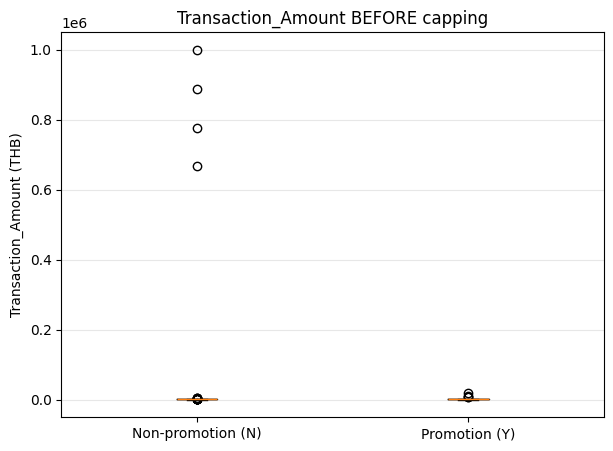

,count,mean,std,min,25%,50%,75%,max
Is_Promotion,,,,,,,,
N,585.0,6427.38,69438.1,-500.00,310.80,563.21,1023.48,999999.00
Y,27.0,2395.34,4356.7,115.42,347.96,834.78,1526.08,19610.76


In [27]:
df["Transaction_Amount_Before_Capping"] = df["Transaction_Amount"]

def boxplot(data, title):
    groups = [data.loc[data["Is_Promotion"] != "Y", "Transaction_Amount"],
              data.loc[data["Is_Promotion"] == "Y", "Transaction_Amount"]]
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.boxplot(groups, tick_labels=["Non-promotion (N)", "Promotion (Y)"])
    ax.set_title(title)
    ax.set_ylabel("Transaction_Amount (THB)")
    ax.grid(axis="y", alpha=0.3)
    plt.show()

boxplot(df, "Transaction_Amount BEFORE capping")
df.groupby("Is_Promotion")["Transaction_Amount"].describe().round(2)

In [28]:
# คำนวณ IQR จากรายการที่ไม่ใช่โปรโมชันเท่านั้น
baseline = df.loc[df["Is_Promotion"] != "Y", "Transaction_Amount"]
Q1 = baseline.quantile(0.25)
Q3 = baseline.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"ใช้ {len(baseline)} แถวเป็นฐาน (ตัดโปรโมชัน {int((df['Is_Promotion'] == 'Y').sum())} แถวออก)")
print(f"Q1={Q1:,.2f}  Q3={Q3:,.2f}  IQR={IQR:,.2f}")
print(f"lower={lower:,.2f}  upper={upper:,.2f}")
metrics.update(iqr_q1=round(float(Q1), 2), iqr_q3=round(float(Q3), 2),
               iqr_lower_bound=round(float(lower), 2), iqr_upper_bound=round(float(upper), 2))

ใช้ 585 แถวเป็นฐาน (ตัดโปรโมชัน 27 แถวออก)
Q1=310.80  Q3=1,023.48  IQR=712.68
lower=-758.22  upper=2,092.50


In [29]:
# ติด flag ก่อนแก้ค่า และแยกให้ชัดว่าแถวไหน "จะถูกแก้" จริง
df["Outlier_Flag_Before_Capping"] = ~df["Transaction_Amount"].between(lower, upper)
df["Amount_Was_Capped"] = df["Outlier_Flag_Before_Capping"] & (df["Is_Promotion"] != "Y")

print(f"อยู่นอกขอบเขต {df['Outlier_Flag_Before_Capping'].sum()} แถว "
      f"(เป็นโปรโมชัน {int((df['Outlier_Flag_Before_Capping'] & (df['Is_Promotion'] == 'Y')).sum())} แถว -> ไม่แก้)")
print(df.loc[df["Outlier_Flag_Before_Capping"],
             ["Transaction_ID", "Quantity", "Unit_Price", "Transaction_Amount", "Expected_Amount",
              "Is_Promotion", "Amount_Was_Capped"]].to_string(index=False))

อยู่นอกขอบเขต 25 แถว (เป็นโปรโมชัน 6 แถว -> ไม่แก้)
Transaction_ID  Quantity  Unit_Price  Transaction_Amount  Expected_Amount Is_Promotion  Amount_Was_Capped
       T000095         6      571.14             3426.84          3426.84            N               True
       T000375         6      480.57             2883.42          2883.42            N               True
       T000461         5      538.57             2692.85          2692.85            N               True
       T000403         5      776.68             3495.06          3495.06            N               True
       T000176         6      408.72             2329.70          2329.70            N               True
       T000282         6      183.90            11530.53          1048.23            Y              False
       T000298         2      187.88             3043.62           338.18            Y              False
       T000148         6      350.59             2103.54          2103.54            N              

In [30]:
# Capping ด้วย clip() เฉพาะแถวที่ไม่ใช่โปรโมชัน
to_cap = df["Amount_Was_Capped"]
df.loc[to_cap, "Transaction_Amount"] = df.loc[to_cap, "Transaction_Amount"].clip(lower, upper)
print(f"แก้ค่าไป {int(to_cap.sum())} แถว")
print(df.loc[to_cap, ["Transaction_ID", "Transaction_Amount_Before_Capping", "Transaction_Amount",
                      "Expected_Amount", "Accuracy_Flag"]].to_string(index=False))
print(f"\nในจำนวนนี้ {int((~df.loc[to_cap, 'Accuracy_Flag']).sum())} แถวมียอดเดิม*ตรงสูตรเป๊ะ* "
      f"(ไม่ใช่ข้อมูลผิด แต่ถูกตัดยอดเพราะเป็นออเดอร์ใหญ่) -> ใช้ตอบคำถาม 5")

# ตรวจข้อกำหนดสำคัญของโจทย์
promo = df["Is_Promotion"] == "Y"
assert (df.loc[promo, "Transaction_Amount"] == df.loc[promo, "Transaction_Amount_Before_Capping"]).all()
print(f"\nยืนยัน: รายการโปรโมชัน {int(promo.sum())} แถว มียอดเท่าเดิมทุกบาท")
metrics.update(outliers_detected=int(df["Outlier_Flag_Before_Capping"].sum()),
               outliers_capped=int(to_cap.sum()),
               promotion_outliers_kept=int((df["Outlier_Flag_Before_Capping"] & promo).sum()))

แก้ค่าไป 19 แถว
Transaction_ID  Transaction_Amount_Before_Capping  Transaction_Amount  Expected_Amount  Accuracy_Flag
       T000095                            3426.84              2092.5          3426.84          False
       T000375                            2883.42              2092.5          2883.42          False
       T000461                            2692.85              2092.5          2692.85          False
       T000403                            3495.06              2092.5          3495.06          False
       T000176                            2329.70              2092.5          2329.70          False
       T000148                            2103.54              2092.5          2103.54          False
       T000564                            2999.86              2092.5          2999.86          False
       T000439                          666666.00              2092.5           282.99           True
       T000255                          777777.00              209

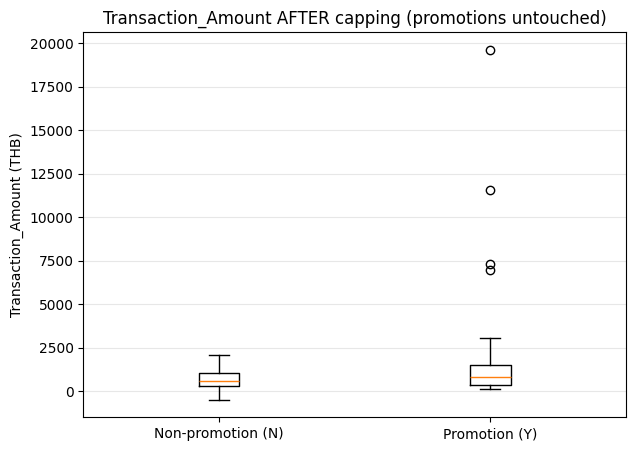

,count,mean,std,min,25%,50%,75%,max
Is_Promotion,,,,,,,,
N,585.0,726.71,534.58,-500.00,310.80,563.21,1023.48,2092.50
Y,27.0,2395.34,4356.70,115.42,347.96,834.78,1526.08,19610.76


In [31]:
boxplot(df, "Transaction_Amount AFTER capping (promotions untouched)")
df.groupby("Is_Promotion")["Transaction_Amount"].describe().round(2)

### อ่านผลจาก Boxplot

**ก่อน capping** กล่องของทั้งสองกลุ่มถูกบีบแบนจนมองไม่เห็น เพราะสเกลของแกน y ถูกยืดโดยค่า sentinel
`999999`, `888888`, `777777`, `666666` — เป็นภาพคลาสสิกของ outlier ที่กลืนการกระจายตัวจริงของข้อมูล

**หลัง capping** กลุ่ม non-promotion เห็นการกระจายตัวจริง (median ~563 บาท สูงสุดเท่ากับ upper bound 2,092.50)
ส่วนกลุ่ม promotion **ยังมีหางยาวถึง 19,610.76 บาทเหมือนเดิม** เพราะไม่ถูกแตะเลยแม้แถวเดียว

### คำถาม 5 — ทำไมข้อมูลนอก IQR bound จึงไม่จำเป็นต้องผิดเสมอ

**เพราะ IQR วัด "ความหายากทางสถิติ" ไม่ได้วัด "ความถูกผิดทางธุรกิจ"** — ขอบเขต `Q1 − 1.5·IQR` ถึง `Q3 + 1.5·IQR`
คำนวณจากการกระจายตัวของตัวเลขล้วน ๆ มันไม่รู้ว่าคอลัมน์นี้คือยอดขาย ไม่รู้ว่ามีแคมเปญ และไม่รู้ว่ายอดติดลบเป็นไปไม่ได้
ค่าที่หลุดขอบเขตจึงแปลได้แค่ว่า "หายากเมื่อเทียบกับแถวอื่น" ซึ่งเป็น **สัญญาณให้ไปตรวจ ไม่ใช่คำตัดสินว่าผิด**

**ตัวอย่างที่ 1 — outlier ที่เป็นข้อมูลจริง (จาก dataset นี้)**
รายการโปรโมชัน 6 แถวหลุด upper bound เช่น `T000406` ยอด 19,610.76 บาท และ `T000282` ยอด 11,530.53 บาท
ทั้งหมดเป็นธุรกรรมแคมเปญที่เกิดขึ้นจริง การ cap จะเท่ากับลบยอดขายแคมเปญทิ้ง — notebook นี้จึงเก็บค่าเดิมไว้ทุกบาท
แต่ยังติด `Outlier_Flag_Before_Capping` ไว้ให้ตรวจย้อนได้

**ตัวอย่างที่ 2 — outlier ที่ "ถูกต้องทางคณิตศาสตร์" แต่ยังถูก cap**
ใน 19 แถวที่ถูก cap มี 15 แถวที่ไม่ใช่ sentinel และ **14 แถวในนั้นมียอดตรงสูตร `Qty × Price × (1 − Disc)` เป๊ะ**
เช่น `T000551` = 6 × 618.74 = 3,712.44 บาท (Sports) และ `T000403` = 5 × 776.68 × 0.9 = 3,495.06 บาท
— เป็นออเดอร์ใหญ่ที่ถูกต้องทุกบาท แต่ถูกตัดลงเหลือ 2,092.50 ทำให้ยอดขายจริงหายไป **9,933.25 บาท**
นี่คือ **ต้นทุนของการ capping** ที่ต้องยอมรับเพื่อกันค่า sentinel และเป็นเหตุผลที่ต้องเก็บ
`Transaction_Amount_Before_Capping` ไว้เสมอ เพื่อให้ย้อนกลับได้ถ้าฝ่ายธุรกิจยืนยันว่าเป็นยอดจริง

**ตัวอย่างที่ 3 — ข้อมูลผิดที่ IQR จับไม่ได้ (ด้านกลับของคำถาม)**
`lower bound` ของข้อมูลชุดนี้คือ **−758.22** ซึ่งติดลบอยู่แล้ว ทำให้ยอด `−1.00` และ `−500.00`
ถูกมองว่า "อยู่ในขอบเขตปกติ" ทั้งที่เป็นไปไม่ได้ในทางธุรกิจ สรุปได้ว่า
**outlier ≠ error และ error ≠ outlier** — ต้องใช้ business rule (Task 5) ควบคู่กับสถิติเสมอ

### ทำไมต้องแยกโปรโมชันออกจากทั้งการคำนวณ IQR และการ capping

1. **ถ้าเอายอดโปรโมชันมาคำนวณ IQR ด้วย** ขอบเขตจะกว้างเกินจริง แล้ว outlier ที่เป็นข้อมูลผิดพลาดจริง ๆ
   จะรอดเข้าไปในคลังข้อมูล
2. **ถ้า cap ยอดโปรโมชันด้วย** จะไปตัดยอดขายของแคมเปญที่เป็นธุรกรรมจริงและมีคุณค่าทางธุรกิจ
   (เช่นลูกค้าซื้อยกลังในวัน 6.6) ทำให้รายงานผลแคมเปญต่ำกว่าความจริง

รายการโปรโมชัน 6 แถวที่หลุดขอบเขตจึงคงค่าเดิมไว้ทุกบาท แต่ไม่ได้ถูกปล่อยผ่านไปเงียบ ๆ — ยังติด
`Outlier_Flag_Before_Capping` และส่วนใหญ่ติด `Accuracy_Flag` ไว้ด้วย

---
## Task 7 — Timeliness, Report และ Export

In [32]:
df["Load_Delay_Hours"] = ((df["Load_Timestamp"] - df["Order_Date"]).dt.total_seconds() / 3600).round(1)
df["Timeliness_Status"] = (df["Load_Delay_Hours"] > TIMELINESS_SLA_HOURS).map({True: "Late", False: "On Time"})
assert (df["Load_Delay_Hours"] >= 0).all()

n_late = int((df["Timeliness_Status"] == "Late").sum())
print(df["Load_Delay_Hours"].describe().round(1).to_string())
print(f"\nSLA = {TIMELINESS_SLA_HOURS} ชม. -> Late {n_late} แถว ({n_late / len(df) * 100:.1f}%), "
      f"On Time {len(df) - n_late} แถว")
print("\n5 อันดับที่ล่าช้าที่สุด:")
print(df.nlargest(5, "Load_Delay_Hours")[
    ["Transaction_ID", "Order_Date", "Load_Timestamp", "Load_Delay_Hours", "Order_Date_Parse_Method"]
].to_string(index=False))

count    612.0
mean      14.3
std       19.3
min        1.0
25%        5.0
50%       10.0
75%       16.0
max      118.0

SLA = 24 ชม. -> Late 38 แถว (6.2%), On Time 574 แถว

5 อันดับที่ล่าช้าที่สุด:
Transaction_ID Order_Date      Load_Timestamp  Load_Delay_Hours           Order_Date_Parse_Method
       T000047 2026-04-04 2026-04-08 22:00:00             118.0              IDENTICAL_EITHER_WAY
       T000010 2026-05-09 2026-05-13 20:00:00             116.0                   ISO_UNAMBIGUOUS
       T000213 2026-05-21 2026-05-25 19:00:00             115.0                   ISO_UNAMBIGUOUS
       T000132 2026-05-16 2026-05-20 17:00:00             113.0                   ISO_UNAMBIGUOUS
       T000497 2026-01-31 2026-02-04 17:00:00             113.0 RESOLVED_BY_CALENDAR (DD/MM/YYYY)


In [33]:
# before metric ของ Timeliness วัดได้เฉพาะแถวที่วันที่อ่านออกตั้งแต่ต้น
raw_dates = pd.to_datetime(raw["Order_Date"], format="%Y-%m-%d", errors="coerce")
raw_load = pd.to_datetime(raw["Load_Timestamp"])
measurable = raw_dates.notna()
raw_delay = (raw_load[measurable] - raw_dates[measurable]).dt.total_seconds() / 3600
n_unmeasurable = int((~measurable).sum())

sentinel_after = int((df["Transaction_Amount"].round().astype("int64").astype(str).str.match(r"^(\d)\1{5}$")
                      & (df["Transaction_Amount"] >= 100_000)).sum())

report = pd.DataFrame([
    ("Overall", "จำนวนแถวทั้งหมด", metrics["rows_raw"], len(df)),
    ("Completeness", "Customer_Email ว่าง", metrics["missing_email_before"], int(df["Customer_Email"].isna().sum())),
    ("Completeness", "Province ว่าง", metrics["missing_province_before"], int(df["Province"].isna().sum())),
    ("Uniqueness", "แถวซ้ำทั้งแถว (exact duplicate)", metrics["exact_duplicates_before"], int(df.duplicated().sum())),
    ("Uniqueness", "Transaction_ID ซ้ำ", metrics["exact_duplicates_before"], int(df["Transaction_ID"].duplicated().sum())),
    ("Consistency", "จำนวนรูปแบบของ Gender", metrics["distinct_gender_before"], int(df["Gender"].nunique())),
    ("Consistency", "จำนวนรูปแบบของ Payment_Method", metrics["distinct_payment_before"], int(df["Payment_Method"].nunique())),
    ("Consistency", "จำนวนรูปแบบของ Order_Status", metrics["distinct_status_before"], int(df["Order_Status"].nunique())),
    ("Consistency", "Order_Date ที่ไม่อยู่ในรูป YYYY-MM-DD", n_unmeasurable, 0),
    ("Validity", f"Quantity นอกช่วง {QUANTITY_MIN}-{QUANTITY_MAX}", metrics["invalid_quantity_before"],
     int((~df["Quantity"].between(QUANTITY_MIN, QUANTITY_MAX)).sum())),
    ("Validity", "Order_Status ที่ยังไม่อยู่ใน 4 ค่ามาตรฐาน", metrics["invalid_status_fixed"],
     int((~df["Order_Status"].isin(VALID_STATUS - {"Unknown"})).sum())),
    ("Validity", "Transaction_Amount ติดลบ (ติด flag ไว้ ไม่แก้ค่า)", metrics["negative_amount_before"],
     int((df["Transaction_Amount"] < 0).sum())),
    ("Validity", "Transaction_Amount ที่เป็นค่า sentinel", metrics["sentinel_amount_rows"], sentinel_after),
    ("Accuracy", "ยอดไม่ตรงสูตรเกิน 1 บาท (ไม่แก้ค่า รอ business ตรวจ)", metrics["accuracy_mismatch"],
     int(df["Accuracy_Flag"].sum())),
    ("Accuracy", "Outlier ตาม IQR (นับรวมโปรโมชัน)", metrics["outliers_detected"],
     int((~df["Transaction_Amount"].between(lower, upper)).sum())),
    ("Timeliness", "แถวที่วัด Load_Delay_Hours ไม่ได้เพราะวันที่เสีย", n_unmeasurable,
     int(df["Load_Delay_Hours"].isna().sum())),
    ("Timeliness", f"แถวที่ล่าช้ากว่า {TIMELINESS_SLA_HOURS} ชม. (before วัดได้เฉพาะ {int(measurable.sum())} แถว)",
     int((raw_delay > TIMELINESS_SLA_HOURS).sum()), n_late),
    ("Overall", "ยอดขายรวม (บาท)", round(metrics["total_amount_before"], 2), round(float(df["Transaction_Amount"].sum()), 2)),
    ("Overall", f"ยอดขายรวมเมื่อตัดค่า sentinel {metrics['sentinel_amount_rows']} แถวออก (บาท)",
     round(metrics["total_amount_before"] - metrics["sentinel_amount_total"], 2),
     round(float(df["Transaction_Amount"].sum()), 2)),
], columns=["Dimension", "Metric", "Before", "After"])
report["Change"] = report["After"] - report["Before"]
report

,Dimension,Metric,Before,After,Change
0,Overall,จำนวนแถวทั้งหมด,630.00,612.00,-18.00
1,Completeness,Customer_Email ว่าง,50.00,0.00,-50.00
2,Completeness,Province ว่าง,12.00,0.00,-12.00
3,Uniqueness,แถวซ้ำทั้งแถว (exact duplicate),18.00,0.00,-18.00
4,Uniqueness,Transaction_ID ซ้ำ,18.00,0.00,-18.00
5,Consistency,จำนวนรูปแบบของ Gender,10.00,2.00,-8.00
6,Consistency,จำนวนรูปแบบของ Payment_Method,14.00,4.00,-10.00
7,Consistency,จำนวนรูปแบบของ Order_Status,7.00,5.00,-2.00
8,Consistency,Order_Date ที่ไม่อยู่ในรูป YYYY-MM-DD,281.00,0.00,-281.00
9,Validity,Quantity นอกช่วง 1-20,3.00,0.00,-3.00


In [34]:
export_df = df.copy()
export_df["Order_Date"] = export_df["Order_Date"].dt.strftime("%Y-%m-%d")
export_df["Load_Timestamp"] = export_df["Load_Timestamp"].dt.strftime("%Y-%m-%d %H:%M:%S")

export_df.to_csv(CLEAN_PATH, index=False, encoding="utf-8-sig")
report.to_csv(REPORT_PATH, index=False, encoding="utf-8-sig")

print(f"{CLEAN_PATH.name:24s}: {export_df.shape[0]} แถว {export_df.shape[1]} คอลัมน์")
print(f"{REPORT_PATH.name:24s}: {report.shape[0]} ตัวชี้วัด")
print(f"บันทึกไว้ที่ {CLEAN_PATH.parent}")
print("\nencoding = utf-8-sig เพื่อให้ Excel อ่านภาษาไทยไม่เพี้ยน")
print("\nคอลัมน์ flag ที่ติดไว้เพื่อ audit:")
print([c for c in export_df.columns if c.endswith(("_Was_Missing", "_From_Reference", "_Was_Imputed",
                                                   "_Was_Invalid", "_Flag", "_Was_Capped", "_Was_Negative",
                                                   "_Like_Sentinel"))])

e_commerce_clean.csv    : 612 แถว 36 คอลัมน์


data_quality_report.csv : 19 ตัวชี้วัด
บันทึกไว้ที่ D:\work\data_warehouse\03_data_quality_cleaning\data

encoding = utf-8-sig เพื่อให้ Excel อ่านภาษาไทยไม่เพี้ยน

คอลัมน์ flag ที่ติดไว้เพื่อ audit:
['Customer_Email_Was_Missing', 'Province_Was_Missing', 'Customer_Email_Filled_From_Reference', 'Province_Filled_From_Reference', 'Order_Date_Was_Imputed', 'Quantity_Was_Invalid', 'Accuracy_Flag', 'Amount_Was_Negative', 'Amount_Looks_Like_Sentinel', 'Status_Was_Invalid', 'Amount_Was_Capped']


---
## สรุปคำตอบคำถามทั้ง 5 ข้อ

In [35]:
# ตัวเลขประกอบคำตอบสรุปทั้ง 5 ข้อ
print(f"[คำถาม 1] ปัญหาที่พบครอบคลุม 6 มิติ | แถว {metrics['rows_raw']} -> {len(df)} | "
      f"คอลัมน์ {raw.shape[1]} -> {df.shape[1]} (เพิ่มคอลัมน์ flag เพื่อ audit)")

lost_amt = metrics["sales_at_risk_if_dropped"]
real_total = metrics["total_amount_before"] - metrics["sentinel_amount_total"]
print(f"[คำถาม 2] Customer_Email หายในข้อมูลดิบ {metrics['missing_email_before']} แถว "
      f"(เหลือ {int(df['Customer_Email_Was_Missing'].sum())} แถวหลังลบแถวซ้ำ) = {lost_amt:,.2f} บาท "
      f"= {lost_amt / metrics['total_amount_before'] * 100:.2f}% ของยอดดิบ "
      f"หรือ {lost_amt / real_total * 100:.2f}% เมื่อตัดค่า sentinel ออกจากตัวหาร -> เติมครบ ไม่ drop แม้แถวเดียว")

print("\n[คำถาม 3] ตัวอย่างวันที่กำกวมและหลักฐานที่ใช้ตัดสิน:")
print(df[df["Transaction_ID"] == "T900009"][
    ["Transaction_ID", "Order_Date_Raw", "Load_Timestamp", "Order_Date",
     "Order_Date_Parse_Method", "Load_Delay_Hours"]].to_string(index=False))

print(f"\n[คำถาม 4] ยอดไม่ตรงสูตร {metrics['accuracy_mismatch']} แถว "
      f"(โปรโมชัน {metrics['accuracy_mismatch_promotion']} แถว) -> ไม่แก้ค่าแม้แถวเดียว ติด flag ไว้ทั้งหมด")

print(f"[คำถาม 5] outlier {metrics['outliers_detected']} แถว -> cap {metrics['outliers_capped']} แถว, "
      f"เก็บโปรโมชันไว้ {metrics['promotion_outliers_kept']} แถว | "
      f"ยอดจริงที่ถูก capping ตัดออก (ไม่รวม sentinel) = "
      f"{(df.loc[df['Amount_Was_Capped'] & ~df['Amount_Looks_Like_Sentinel'], 'Transaction_Amount_Before_Capping'] - df.loc[df['Amount_Was_Capped'] & ~df['Amount_Looks_Like_Sentinel'], 'Transaction_Amount']).sum():,.2f} บาท")

print("\n[Bonus TODO 4.2] ชื่อที่ตาเห็นว่าเหมือนแต่ byte ไม่เท่ากัน:")
print(df[df["Customer_ID"] == "C0047"][
    ["Transaction_ID", "Customer_Name", "Customer_Name_Normalized", "Customer_Email"]].to_string(index=False))

[คำถาม 1] ปัญหาที่พบครอบคลุม 6 มิติ | แถว 630 -> 612 | คอลัมน์ 16 -> 36 (เพิ่มคอลัมน์ flag เพื่อ audit)


[คำถาม 2] Customer_Email หายในข้อมูลดิบ 50 แถว (เหลือ 48 แถวหลังลบแถวซ้ำ) = 39,254.24 บาท = 1.02% ของยอดดิบ หรือ 7.78% เมื่อตัดค่า sentinel ออกจากตัวหาร -> เติมครบ ไม่ drop แม้แถวเดียว

[คำถาม 3] ตัวอย่างวันที่กำกวมและหลักฐานที่ใช้ตัดสิน:
Transaction_ID Order_Date_Raw      Load_Timestamp Order_Date          Order_Date_Parse_Method  Load_Delay_Hours
       T900009     04/03/2026 2026-04-03 17:00:00 2026-04-03 RESOLVED_BY_LOAD_TS (MM/DD/YYYY)              17.0

[คำถาม 4] ยอดไม่ตรงสูตร 49 แถว (โปรโมชัน 7 แถว) -> ไม่แก้ค่าแม้แถวเดียว ติด flag ไว้ทั้งหมด
[คำถาม 5] outlier 25 แถว -> cap 19 แถว, เก็บโปรโมชันไว้ 6 แถว | ยอดจริงที่ถูก capping ตัดออก (ไม่รวม sentinel) = 9,933.25 บาท

[Bonus TODO 4.2] ชื่อที่ตาเห็นว่าเหมือนแต่ byte ไม่เท่ากัน:
Transaction_ID Customer_Name Customer_Name_Normalized            Customer_Email
       T000088   Ploy Saelim              Ploy Saelim ploy.saelim47@example.com
       T900011  Ploy  Saelim              Ploy Saelim ploy.saelim47@example.com
       T000413  

### สรุปคำตอบแบบสั้น (รายละเอียดเต็มอยู่ท้าย Task ที่เกี่ยวข้อง)

**คำถาม 1 — ปัญหาและมิติ Data Quality**
พบ 12 ปัญหา ครบทั้ง 6 มิติ: *Completeness* (`Customer_Email` ว่าง 50, `Province` ว่าง 12),
*Consistency* (`Gender` 10 รูปแบบ, `Payment_Method` 14 รูปแบบ, `Order_Date` 4 รูปแบบและกำกวม),
*Uniqueness* (แถวซ้ำ 18, near duplicate `Ploy  Saelim`), *Validity* (`Quantity` นอกช่วง 3, `Order_Status` เพี้ยน 16,
ยอดติดลบ 2), *Accuracy* (ยอดไม่ตรงสูตร 49, sentinel 4), *Timeliness* (โหลดช้ากว่า SLA 38 แถว)
→ ตารางเต็มอยู่ใน Task 1

**คำถาม 2 — `dropna()` และ mean imputation**
`dropna()` บน `Customer_Email` จะทำให้ Fact row หาย 50 แถว = ยอดขาย 39,254.24 บาท
(1.02% ของยอดดิบ หรือ 7.78% ของยอดที่ตัดค่า sentinel ออกแล้ว) หายแบบไม่มีร่องรอย
และเกิด bias เชิงระบบถ้าอีเมลหายเฉพาะบางช่องทางขาย ส่วน mean imputation ใช้ไม่ได้เพราะอีเมลเป็น identifier ประเภทข้อความ
ไม่มีค่ากลาง การเติมด้วย mode จะยกธุรกรรมของคนหนึ่งไปให้อีกคนและทำลาย uniqueness
→ ใช้ reference table เติมได้ 47 แถว ที่เหลือ 3 แถวใช้ placeholder ที่ traceable + flag

**คำถาม 3 — วันที่กำกวม**
`T900009` มี `Order_Date = 04/03/2026` ซึ่งเป็นได้ทั้ง 4 มี.ค. และ 3 เม.ย. ใช้ `Load_Timestamp = 2026-04-03 17:00`
เป็นหลักฐานตัดสิน เพราะการตีความแบบ `DD/MM` ให้ delay 744 ชม. ขณะที่ `MM/DD` ให้ 17 ชม. ซึ่งตรงกับ pattern
ของ 409 แถวที่ไม่กำกวม (delay 1–116 ชม. ไม่ติดลบเลย) → ตัดสินว่าเป็น **2026-04-03**

**คำถาม 4 — ยอดไม่ตรงสูตร**
ไม่ควรแก้ทุกแถว 49 แถวแยกเป็น โปรโมชัน 7 (ratio เป็นจำนวนเต็ม ×9–×16 → ห้ามแก้),
sentinel 4 (ผิดแน่นอน), ติดลบ 2 (อาจเป็น refund), ที่เหลือ 36 (ส่งให้ business ตรวจ)
`Is_Promotion` คือ context ที่เปลี่ยนคำตัดสินจาก "ผิด" เป็น "อธิบายได้" และเป็นตัวกันไม่ให้ยอดแคมเปญกว่า 47,000 บาทถูกลบทิ้ง

**คำถาม 5 — outlier ไม่จำเป็นต้องผิด**
IQR วัดความหายากทางสถิติ ไม่ได้วัดความถูกผิดทางธุรกิจ ในชุดนี้มีทั้ง outlier ที่ถูกต้อง
(โปรโมชัน 6 แถว และออเดอร์ใหญ่ 14 แถวที่ยอดตรงสูตรเป๊ะ — การ cap ตัดยอดจริงออกไป 9,933.25 บาท)
และข้อมูลผิดที่ IQR จับไม่ได้ (ยอด −1.00 / −500.00 ยังอยู่ในขอบเขตเพราะ lower bound = −758.22)

**Bonus (TODO 4.2) — ทำไม `drop_duplicates()` ไม่เห็น near duplicate**
เพราะเทียบแบบตรงตัวทุก byte `'Ploy  Saelim' == 'Ploy Saelim'` จึงเป็น `False`
ต้อง normalize + ใช้ secondary key (`Customer_Email`, `Customer_ID`) + fuzzy matching และให้คนยืนยันก่อนรวม

---
## Reflection

**1. ขั้นตอนใดเสี่ยงทำให้ข้อมูลจริงสูญหายมากที่สุด**

เรียงจากเสี่ยงมากไปน้อยตามที่เจอจริงใน lab นี้

- **`dropna()` บนคอลัมน์ของ dimension** — เสี่ยงที่สุดเพราะทำให้ Fact row หายทั้งแถว ในชุดนี้คือ 50 แถว
  และยอดขาย 39,254.24 บาท ทั้งที่ปัญหาอยู่แค่ attribute เดียว
- **IQR capping** — เสี่ยงเงียบที่สุด เพราะไม่ได้ลบแถว แต่ *แก้ตัวเลข* 15 แถวที่ไม่ใช่ sentinel
  ซึ่ง 14 แถวในนั้นยอดตรงสูตรเป๊ะอยู่แล้ว รวมยอดจริงที่หายไป 9,933.25 บาท ถ้าไม่เก็บ
  `Transaction_Amount_Before_Capping` ไว้ก็กู้คืนไม่ได้เลย
- **`drop_duplicates()` ที่เลือก subset ผิด** — ถ้าใช้ `subset=["Customer_ID", "Order_Date"]` จะลบธุรกรรมคนละรายการ
  ของลูกค้าคนเดียวกันในวันเดียวกันทิ้ง notebook นี้จึงเทียบทุกคอลัมน์เชิงธุรกิจ และแยก near duplicate ออกมา
  **รายงานอย่างเดียวโดยไม่ลบ**
- **การเขียน `Expected_Amount` ทับ `Transaction_Amount`** — ทำลายหลักฐานว่าระบบต้นทางส่งอะไรมา
  และปิดบัง bug ที่ต้นทางไม่ให้ถูกแก้

หลักที่ใช้กันความเสี่ยงทั้งหมดนี้คือ **ติด flag ก่อนแก้ + เก็บค่าเดิมไว้เสมอ** ทำให้ทุกการเปลี่ยนแปลงย้อนกลับได้

**2. กฎใดควรนำไปทำ Automation ใน Data Pipeline**

*ควร automate (deterministic ทำซ้ำได้ ไม่ต้องตีความ)*

| กฎ | ตำแหน่งใน pipeline | ทำอะไรเมื่อไม่ผ่าน |
|---|---|---|
| schema + dtype ตรงตามสัญญา | ทันทีที่รับไฟล์ | ปฏิเสธไฟล์ทั้งไฟล์ |
| `Transaction_ID` not null + unique | staging | quarantine แถวที่ซ้ำ |
| ค่าใน allowed set (`Gender`, `Payment_Method`, `Order_Status`) | transform | map + alert เมื่อเจอค่าใหม่ที่ mapping ไม่รู้จัก |
| `Quantity` ระหว่าง 1–20 | transform | clip + ติด flag |
| `Load_Timestamp ≥ Order_Date` | transform | ใช้เป็นหลักฐานแก้วันที่ + alert |
| `\|Transaction_Amount − Expected_Amount\| ≤ 1` | transform | ติด `Accuracy_Flag` ไม่แก้ค่า |
| ตรวจ pattern ของค่า sentinel (`^(\d)\1{5}$`) | transform | quarantine + แจ้งทีมระบบต้นทาง |
| freshness SLA 24 ชม. | หลังโหลด | แจ้งเตือน ไม่บล็อกการโหลด |

*ไม่ควร automate (ต้องมีคนตัดสิน)* — การรวมลูกค้า near duplicate, การแก้ยอดโปรโมชันให้ตรงสูตร
และการตัดสินว่ายอดติดลบเป็น refund หรือข้อมูลผิด เพราะตัดสินผิดแล้วย้อนกลับยากและกระทบยอดขายรายลูกค้าโดยตรง

**3. ถ้าใช้ Great Expectations จะสร้าง Expectation ใดบ้าง**

```python
# Completeness / Uniqueness
validator.expect_column_values_to_not_be_null("Transaction_ID")
validator.expect_column_values_to_be_unique("Transaction_ID")
validator.expect_column_values_to_not_be_null("Customer_ID")

# Validity
validator.expect_column_values_to_be_between("Quantity", min_value=1, max_value=20)
validator.expect_column_values_to_be_between("Discount_Rate", min_value=0, max_value=1)
validator.expect_column_values_to_be_in_set(
    "Payment_Method", ["Credit Card", "PromptPay", "Cash on Delivery", "Bank Transfer", "Unknown"])
validator.expect_column_values_to_be_in_set(
    "Order_Status", ["Completed", "Processing", "Cancelled", "Returned", "Unknown"])

# Consistency (รูปแบบวันที่หลัง clean ต้องเป็นแบบเดียว)
validator.expect_column_values_to_match_strftime_format("Order_Date", "%Y-%m-%d")

# Accuracy / Timeliness (ข้ามคอลัมน์)
validator.expect_column_pair_values_A_to_be_greater_than_B(
    "Load_Timestamp", "Order_Date", or_equal=True)
validator.expect_column_values_to_be_between("Load_Delay_Hours", min_value=0, max_value=24, mostly=0.90)

# ระดับตาราง
validator.expect_table_row_count_to_be_between(min_value=500, max_value=1000)
```

ตั้ง `mostly=0.90` กับ SLA เพราะความล่าช้าบางส่วนเป็นเรื่องปกติของระบบ ควรเป็น **warning** ไม่ใช่ fail
ส่วนกฎที่เป็น hard rule (unique key, allowed set, ช่วงค่า) ให้ fail แล้วหยุด pipeline ทันที
เพื่อไม่ให้ข้อมูลเสียไหลเข้าคลัง

---
## Checklist ก่อนส่ง

- [x] **Notebook รันจากบนลงล่างได้โดยไม่ Error** — รันด้วย `python -m nbconvert --to notebook --execute --inplace dq_lab.ipynb`
      และมี assertion 15 ข้อในเซลล์สุดท้าย
- [x] **มีคำตอบคำถามทั้ง 5 ข้อและ Reflection** — คำตอบเต็มอยู่ท้ายแต่ละ Task และมีสรุปรวมท้าย notebook
- [x] **ส่ง `e_commerce_clean.csv`** — `data/e_commerce_clean.csv` 612 แถว 36 คอลัมน์ (UTF-8-SIG)
- [x] **ส่ง `data_quality_report.csv`** — `data/data_quality_report.csv` 19 ตัวชี้วัด before/after
- [x] **ไม่ลบรายการโปรโมชันเพียงเพราะเป็น Outlier** — โปรโมชัน 27 แถวมียอดเท่าเดิมทุกบาท
      (มี assertion ตรวจไว้) รวมถึง 6 แถวที่หลุด IQR bound
- [x] **ไม่ลบข้อมูลผิดปกติโดยไม่อธิบายเหตุผล** — ที่ลบมีเพียงแถวซ้ำทั้งแถว 18 แถว ส่วนที่เหลือติด flag ไว้ทั้งหมด

---
## ตรวจสอบผลลัพธ์ท้าย notebook

ยืนยันว่าผลจาก notebook ตรงกับ pipeline ใน `dq_lab.py` และผ่านข้อกำหนดทุกข้อ

In [36]:
checks = {
    "จำนวนแถว = 630 - 18 แถวซ้ำ": len(df) == 612,
    "Customer_Email / Province ไม่มีค่าว่าง": not df["Customer_Email"].isna().any() and not df["Province"].isna().any(),
    "Gender อยู่ในชุดมาตรฐาน": not set(df["Gender"].unique()) - VALID_GENDER,
    "Payment_Method อยู่ในชุดมาตรฐาน": not set(df["Payment_Method"].unique()) - VALID_PAYMENT,
    "Order_Status อยู่ในชุดมาตรฐาน": not set(df["Order_Status"].unique()) - VALID_STATUS,
    "Order_Date เป็นวันที่จริงทุกแถว": df["Order_Date"].notna().all(),
    "Order_Date_Was_Imputed = 7 แถว": int(df["Order_Date_Was_Imputed"].sum()) == 7,
    f"Quantity อยู่ในช่วง {QUANTITY_MIN}-{QUANTITY_MAX}": df["Quantity"].between(QUANTITY_MIN, QUANTITY_MAX).all(),
    "Load_Delay_Hours ไม่ติดลบ": (df["Load_Delay_Hours"] >= 0).all(),
    "ยอดติดลบทุกแถวถูก flag ไว้ครบ": ((df["Transaction_Amount"] < 0) == df["Amount_Was_Negative"]).all(),
    "ไม่มีค่า sentinel เหลือหลัง capping": sentinel_after == 0,
    "รายการโปรโมชัน 27 แถวมียอดเท่าเดิมทุกบาท": (
        df.loc[promo, "Transaction_Amount"] == df.loc[promo, "Transaction_Amount_Before_Capping"]).all(),
    "ยอด non-promotion ไม่เกิน upper bound": df.loc[~promo, "Transaction_Amount"].max() <= upper + 1e-6,
    "ตรงกับ pipeline: capped 19 แถว": int(df["Amount_Was_Capped"].sum()) == 19,
    "ตรงกับ pipeline: Late 38 แถว": n_late == 38,
}
for name, ok in checks.items():
    print(f"[{'PASS' if ok else 'FAIL'}] {name}")
assert all(checks.values()), "มีข้อที่ไม่ผ่าน"
print(f"\nผ่านทั้งหมด {len(checks)}/{len(checks)} ข้อ")

[PASS] จำนวนแถว = 630 - 18 แถวซ้ำ
[PASS] Customer_Email / Province ไม่มีค่าว่าง
[PASS] Gender อยู่ในชุดมาตรฐาน
[PASS] Payment_Method อยู่ในชุดมาตรฐาน
[PASS] Order_Status อยู่ในชุดมาตรฐาน
[PASS] Order_Date เป็นวันที่จริงทุกแถว
[PASS] Order_Date_Was_Imputed = 7 แถว
[PASS] Quantity อยู่ในช่วง 1-20
[PASS] Load_Delay_Hours ไม่ติดลบ
[PASS] ยอดติดลบทุกแถวถูก flag ไว้ครบ
[PASS] ไม่มีค่า sentinel เหลือหลัง capping
[PASS] รายการโปรโมชัน 27 แถวมียอดเท่าเดิมทุกบาท
[PASS] ยอด non-promotion ไม่เกิน upper bound
[PASS] ตรงกับ pipeline: capped 19 แถว
[PASS] ตรงกับ pipeline: Late 38 แถว

ผ่านทั้งหมด 15/15 ข้อ
